<a href="https://colab.research.google.com/github/kolijayesh370-ops/walmart-supply-chain-engine/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Ingest the clean data from our previous pipeline execution
data = pd.read_csv("Walmart_Sales_Cleaned.csv")

print("Dataset Dimensions:", data.shape)
print("\nMissing Values Audit:")
print(data.isna().sum())
print("\nDuplicate Check:", data.duplicated().sum())

Dataset Dimensions: (6435, 8)

Missing Values Audit:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate Check: 0


In [ ]:
data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


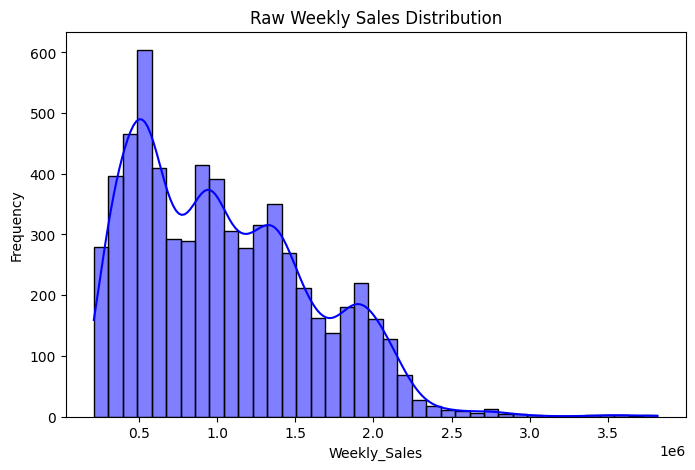

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x="Weekly_Sales", kde=True, color="blue")
plt.title("Raw Weekly Sales Distribution")
plt.ylabel("Frequency")
plt.show()

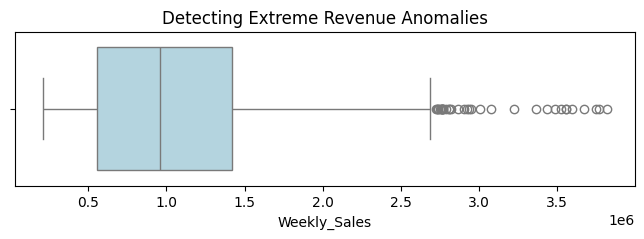

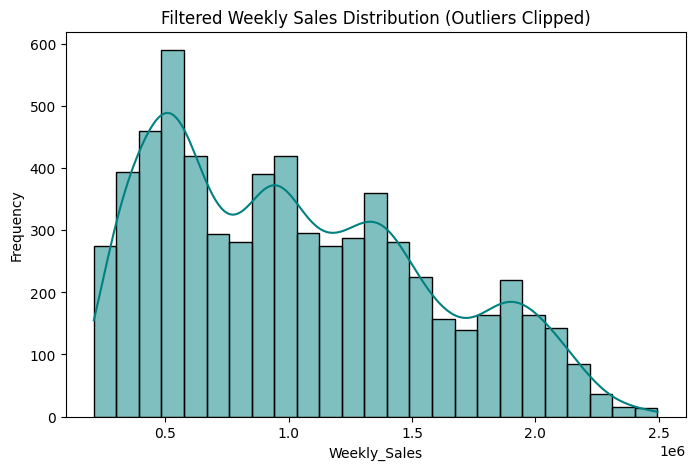

In [ ]:
# Identifying Outliers via boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(data=data, x="Weekly_Sales", color="lightblue")
plt.title("Detecting Extreme Revenue Anomalies")
plt.show()

# Keep rows matching typical high-velocity thresholds (e.g., clipping rare multi-million dollar store-week anomalies)
df = data[data['Weekly_Sales'] < 2500000]

# Plotting finalized distribution after scaling extreme anomalies out
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Weekly_Sales", kde=True, color="teal")
plt.title("Filtered Weekly Sales Distribution (Outliers Clipped)")
plt.ylabel("Frequency")
plt.show()

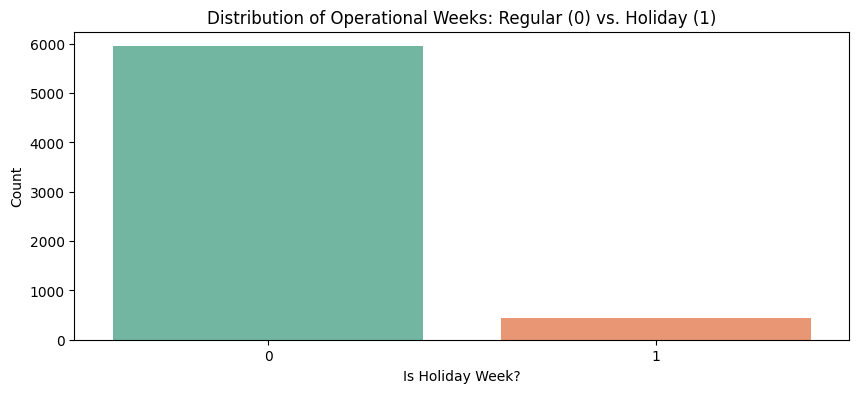

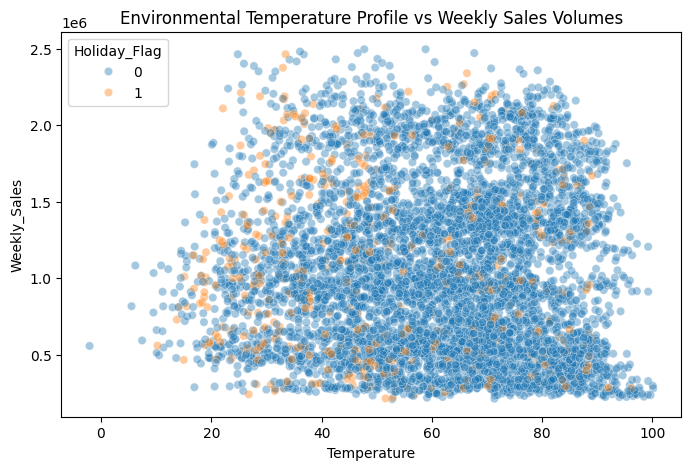

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Holiday_Flag", hue="Holiday_Flag", palette="Set2", legend=False)
plt.title("Distribution of Operational Weeks: Regular (0) vs. Holiday (1)")
plt.xlabel("Is Holiday Week?")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Temperature", y="Weekly_Sales", alpha=0.4, color="coral", hue="Holiday_Flag")
plt.title("Environmental Temperature Profile vs Weekly Sales Volumes")
plt.show()

In [ ]:
# Create engineered variable column
df['sales_per_temp'] = df['Weekly_Sales'] / df['Temperature']

print("Engineered Feature Manifest Verification:")
print(df.columns.tolist())

print("\n--- Mean Performance Metrics Grouped Across Holiday Blocks ---")
print(df.groupby(by="Holiday_Flag")["Weekly_Sales"].mean())

print("\n--- Climatic Footprint Metrics Grouped Across Holiday Blocks ---")
print(df.groupby(by="Holiday_Flag")["sales_per_temp"].mean())

Engineered Feature Manifest Verification:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'sales_per_temp']

--- Mean Performance Metrics Grouped Across Holiday Blocks ---
Holiday_Flag
0    1.029230e+06
1    1.069391e+06
Name: Weekly_Sales, dtype: float64

--- Climatic Footprint Metrics Grouped Across Holiday Blocks ---
Holiday_Flag
0    18903.010546
1    25739.929390
Name: sales_per_temp, dtype: float64


/tmp/ipykernel_786/507215955.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sales_per_temp'] = df['Weekly_Sales'] / df['Temperature']


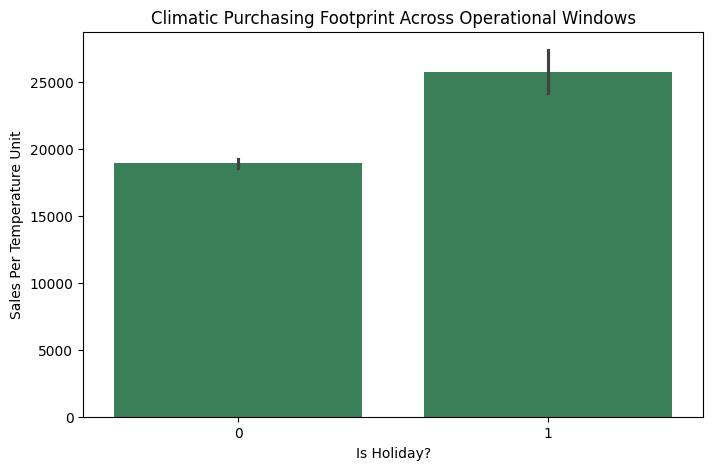

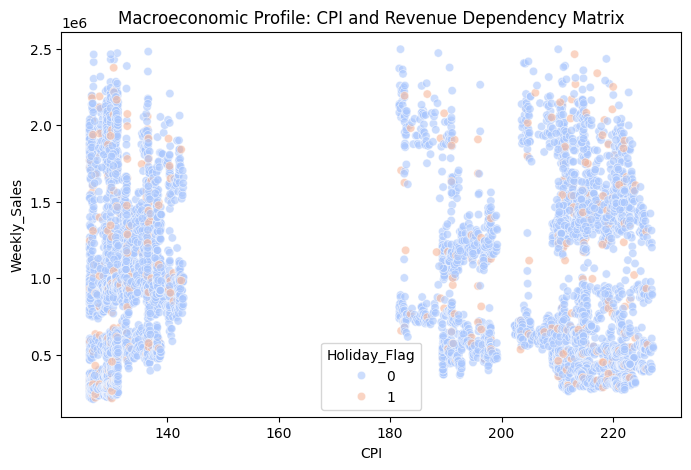

In [ ]:
# Barplot: Holiday Status vs. Weather-Adjusted Sales Metrics
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Holiday_Flag", y="sales_per_temp", color="seagreen")
plt.title("Climatic Purchasing Footprint Across Operational Windows")
plt.xlabel("Is Holiday?")
plt.ylabel("Sales Per Temperature Unit")
plt.show()

# Scatterplot: Tracking Regional Macroeconomic Dependencies
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="CPI", y="Weekly_Sales", hue="Holiday_Flag", palette="coolwarm", alpha=0.6)
plt.title("Macroeconomic Profile: CPI and Revenue Dependency Matrix")
plt.show()

Generating Core Metric Clustering Configurations...


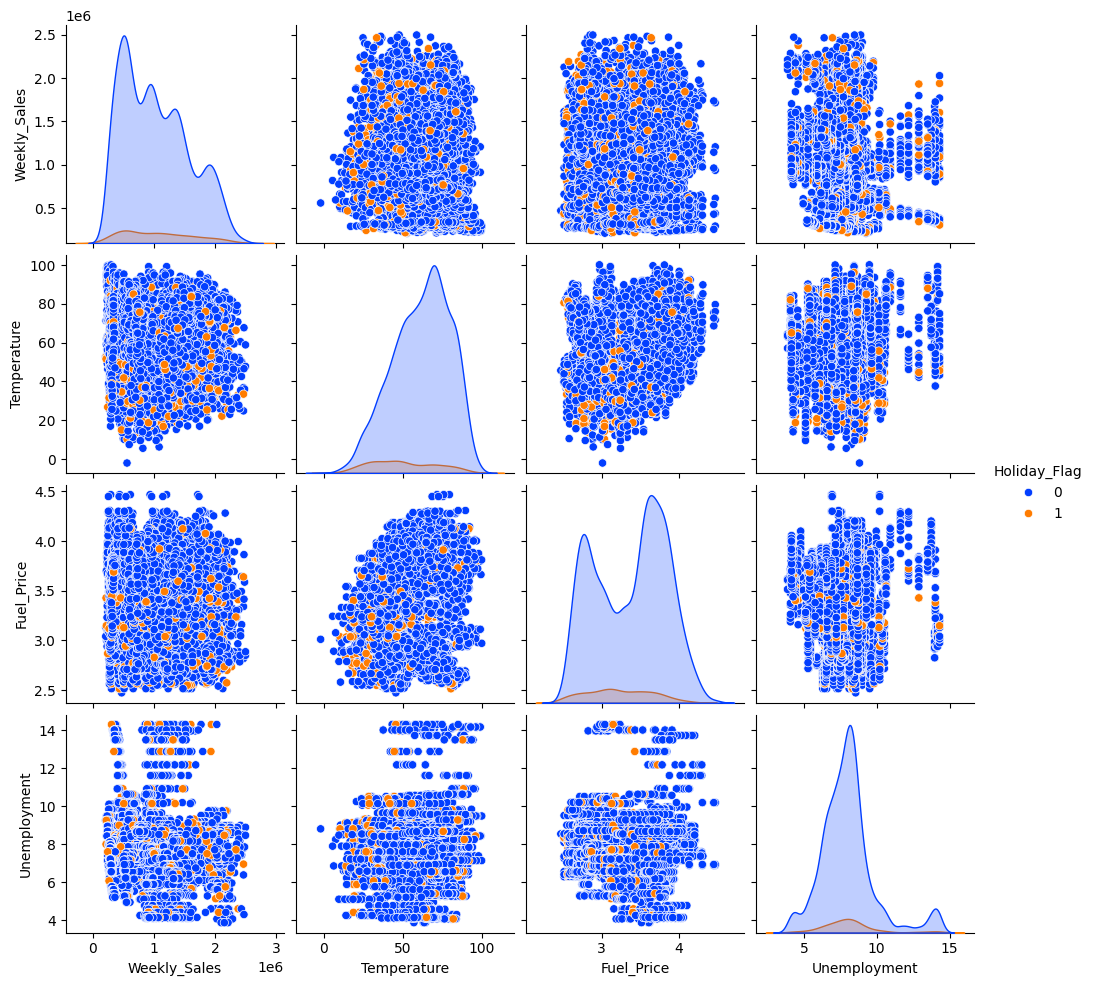

In [ ]:
print("Generating Core Metric Clustering Configurations...")
sns.pairplot(data=df, vars=['Weekly_Sales', 'Temperature', 'Fuel_Price', 'Unemployment'], hue="Holiday_Flag", palette="bright")
plt.show()

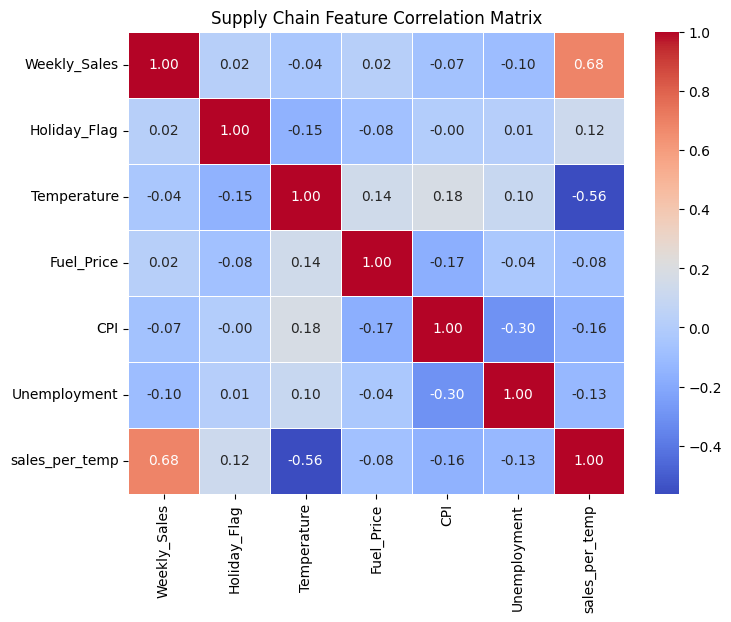

In [ ]:
plt.figure(figsize=(8, 6))
corr = df[['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'sales_per_temp']].corr()
sns.heatmap(data=corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Supply Chain Feature Correlation Matrix")
plt.show()